## Visualization of the TTF artifacts and modifications

In [ ]:
import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '2'

from tqdm import tqdm
import numpy as np
import torch
import normflows as nf
import matplotlib.pyplot as plt
import openturns as ot

# To avoid meshgrid warning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='torch')

from tailnflows.targets.synth_targets import GaussianCopula
from tailnflows.models.extreme_transformations import TailAffineMarginalTransform, ModifiedTailAffineMarginalTransform

torch.cuda.set_device(3)
device = torch.device(f"cuda:{3}" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)
print("Current CUDA device:", torch.cuda.current_device())
print("All CUDA devices:", torch.cuda.device_count())

DEFAULT_DTYPE = torch.float32

Using device:  cuda:3
Current CUDA device: 3
All CUDA devices: 4


### Prepare target distribution

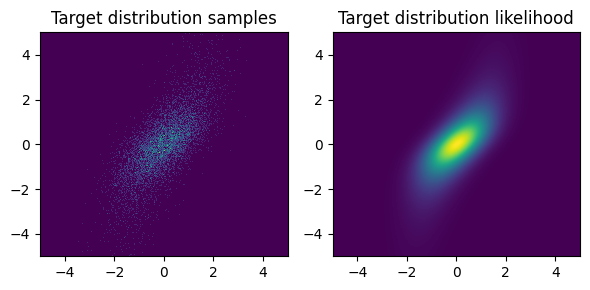

In [2]:
# Mixed-tailed Gaussian Copula target
df = 2.5
target = GaussianCopula(
    num_light = 1,
    num_heavy = 1,
    df = df,
    corr_matrix = ot.CorrelationMatrix(2, (1.0, 0.75, 0.75, 1.0))
)
# Sample from target
x_np = target.sample(32000).detach().cpu().numpy()

# Parameters for plots
x_low, x_high = -5.0, 5.0
y_low, y_high = -5.0, 5.0

range_hist2d = ((x_low,x_high), (y_low, y_high))
extent_imshow = (x_low, x_high, y_low, y_high)

# Prepare grid
bins = 500
grid_size = 500
grid = torch.meshgrid(torch.linspace(x_low, x_high, grid_size), torch.linspace(y_low, y_high, grid_size), indexing='xy')
grid = torch.stack([grid[0].flatten(), grid[1].flatten()], dim=1).to(device)

# Compute likelihood on grid
target_log_p = target.log_prob(grid)
target_likelihood = torch.exp(target_log_p).reshape(grid_size, grid_size)
target_likelihood = target_likelihood.detach().cpu().numpy()

# Create plots
fig, axs = plt.subplots(1, 2, figsize=(6, 3))
axs[0].hist2d(x_np[:, 0], x_np[:, 1], bins=bins, range=range_hist2d, density=True)
axs[0].set_title('Target distribution samples')
axs[1].imshow(target_likelihood, extent=extent_imshow, aspect='auto', origin='lower', cmap='viridis')
axs[1].set_title('Target distribution likelihood')

fig.tight_layout()
fig.show()

### Fit NF models

In [3]:
# Set base distribuiton
q0 = nf.distributions.DiagGaussian(2, trainable=False)
q0 = q0.to(device)

# Define list of flows
num_layers = 3
num_blocks = 2
num_hidden_channels = 64
def build_flows():
    flows = []
    for i in range(num_layers):
        flows += [nf.flows.AutoregressiveRationalQuadraticSpline(2, num_blocks, num_hidden_channels)]
        flows += [nf.flows.LULinearPermute(2)]
    return flows

# Training algorithm
def train(nf_model: nf.NormalizingFlow, num_steps: int = 1000, batch_size: int = 2**9, show_every: int = 100, lr: float = 1e-3):
    # Prepare loss history
    loss_hist = np.array([])

    # Get training samples for initial loss
    x_initial = target.sample(batch_size).float().to(device)
    # Compute initial loss
    loss_initial = nf_model.forward_kld(x_initial)
    # Log initial loss loss
    loss_hist = np.append(loss_hist, loss_initial.to('cpu').data.numpy())

    # Train model
    optimizer = torch.optim.Adam(nf_model.parameters(), lr=lr, weight_decay=1e-5)
    for step in tqdm(range(num_steps)):
        optimizer.zero_grad()
        
        # Get training batch
        x = target.sample(batch_size).float().to(device)
        
        # Compute loss
        loss = nf_model.forward_kld(x)
        
        # Do backprop and optimizer step
        if ~(torch.isnan(loss) | torch.isinf(loss)):
            loss.backward()
            optimizer.step()
        
        # Log loss
        loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())
        
        # Plot learned distribution and print TTF params
        if (step + 1) % show_every == 0:
            nf_model.eval()
            log_prob = nf_model.log_prob(grid).to('cpu')
            nf_model.train()
            prob = torch.exp(log_prob).reshape(grid_size, grid_size)
            prob[torch.isnan(prob)] = 0

            fig, axs = plt.subplots(1, 2, figsize=(6, 3))
            nf_model.eval()
            samples, _ = nf_model.sample(32000)
            samples = samples.detach().cpu().numpy()
            nf_model.train()
            axs[0].hist2d(samples[:, 0], samples[:, 1], bins=bins, range=range_hist2d, density=True)
            axs[0].set_title("Flow samples")
            axs[1].imshow(prob.data.numpy(), extent=extent_imshow, aspect='auto', origin='lower', cmap='viridis')
            axs[1].set_title("Flow likelihood")
            print(f"Current training loss: {loss.to('cpu').data.numpy():.3f}")
            plt.show()

            last_layer = nf_model.flows[-1]
            if isinstance(last_layer, (TailAffineMarginalTransform, ModifiedTailAffineMarginalTransform)):
                print("pos_tail: ", last_layer.pos_tail)
                print("neg_tail: ", last_layer.neg_tail)
                print("shift: ", last_layer.shift)
                print("scale: ", last_layer.scale)
                

    # Plot loss history
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.plot(loss_hist, label='loss')
    ax.set_ylim(0.0, max(loss_hist[0]*1.2, 10.0))
    ax.set_title('Training loss')
    fig.tight_layout()
    fig.show()

    # Plot learned distribution
    nf_model.eval()
    samples, _ = nf_model.sample(32000)
    samples = samples.detach().cpu().numpy()
    log_prob = nf_model.log_prob(grid).to('cpu')
    prob = torch.exp(log_prob).reshape(grid_size, grid_size)
    prob[torch.isnan(prob)] = 0
    fig, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].hist2d(samples[:, 0], samples[:, 1], bins=bins, range=range_hist2d, density=True)
    axs[0].set_title('Learned distribution samples')
    axs[1].imshow(prob.data.numpy(), extent=extent_imshow, aspect='auto', origin='lower', cmap='viridis')
    axs[1].set_title('Learned distribution likelihood')
    fig.tight_layout()
    fig.show()

def debug_first_steps(model_a, model_b, layer_a, layer_b, num_steps=5, batch_size=512, lr=1e-3):
    opt_a = torch.optim.Adam(
        [p for p in model_a.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=1e-5,
    )
    opt_b = torch.optim.Adam(
        [p for p in model_b.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=1e-5,
    )

    for step in range(num_steps):
        x = target.sample(batch_size).float().to(device)

        opt_a.zero_grad()
        loss_a = model_a.forward_kld(x)
        loss_a.backward()

        opt_b.zero_grad()
        loss_b = model_b.forward_kld(x)
        loss_b.backward()

        print("\nSTEP", step)
        print("loss_a", loss_a.item(), "loss_b", loss_b.item(), "diff", (loss_a - loss_b).item())

        print("BEFORE STEP")
        for name in ["_unc_pos_tail", "_unc_neg_tail", "shift", "_unc_scale"]:
            pa = getattr(layer_a, name)
            pb = getattr(layer_b, name)
            ga = pa.grad
            gb = pb.grad
            print(
                name,
                "param diff", (pa - pb).detach().abs().max().item(),
                "grad diff", (ga - gb).detach().abs().max().item(),
                "grad a", ga.detach().cpu().numpy(),
                "grad b", gb.detach().cpu().numpy(),
            )

        before_a = {name: getattr(layer_a, name).detach().clone()
                    for name in ["_unc_pos_tail", "_unc_neg_tail", "shift", "_unc_scale"]}
        before_b = {name: getattr(layer_b, name).detach().clone()
                    for name in ["_unc_pos_tail", "_unc_neg_tail", "shift", "_unc_scale"]}

        opt_a.step()
        opt_b.step()

        print("AFTER STEP / UPDATE DIFF")
        for name in ["_unc_pos_tail", "_unc_neg_tail", "shift", "_unc_scale"]:
            pa = getattr(layer_a, name)
            pb = getattr(layer_b, name)

            upd_a = pa.detach() - before_a[name]
            upd_b = pb.detach() - before_b[name]

            print(
                name,
                "update a", upd_a.cpu().numpy(),
                "update b", upd_b.cpu().numpy(),
                "update diff", (upd_a - upd_b).abs().max().item(),
                "new param diff", (pa - pb).detach().abs().max().item(),
            )
            
def get_nll(nf_model: nf.NormalizingFlow, true_samps: torch.Tensor) -> float:
    nll = -nf_model.log_prob(true_samps.to(DEFAULT_DTYPE)).sum() / (true_samps.shape[0] * 2)
    nll = nll.to('cpu').item()
    return nll

def bin_count(nf_model: nf.NormalizingFlow, true_samps: torch.Tensor, dim: int, bin: tuple = (-0.05, 0.05)) -> tuple[int, int]:
    num_samps = true_samps.shape[0]
    flow_samps, _ = nf_model.sample(num_samps)
    flow_samps = flow_samps[:,dim]
    true_samps = true_samps[:,dim]
    num_true_samps_in_bin = ((bin[0] < true_samps) & (true_samps < bin[1])).sum().item()
    num_flow_samps_in_bin = ((bin[0] < flow_samps) & (flow_samps < bin[1])).sum().item()
    return num_true_samps_in_bin, num_flow_samps_in_bin

### Baseline

 10%|▉         | 97/1000 [00:04<00:37, 23.97it/s]

Current training loss: 3.754


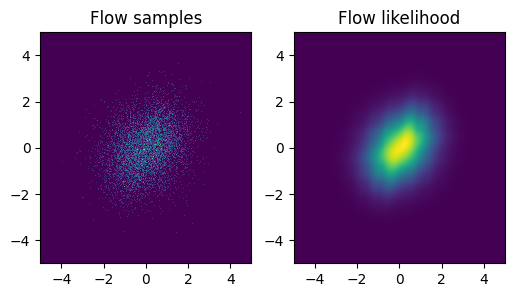

 20%|█▉        | 197/1000 [00:08<00:33, 23.90it/s]

Current training loss: 3.676


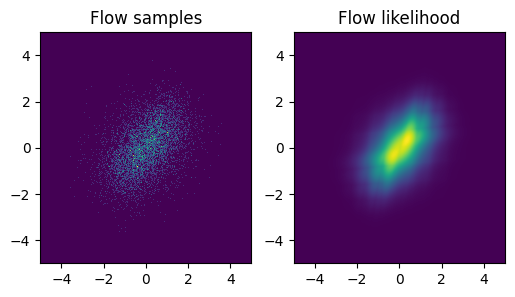

 30%|██▉       | 297/1000 [00:13<00:29, 24.10it/s]

Current training loss: 8.695


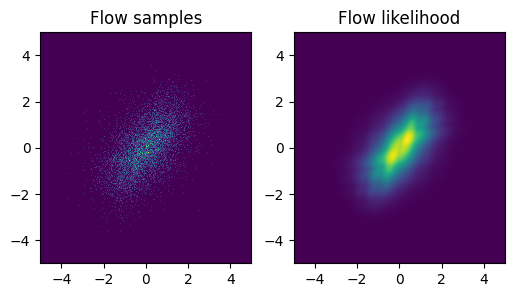

 40%|███▉      | 399/1000 [00:17<00:24, 24.27it/s]

Current training loss: 3.251


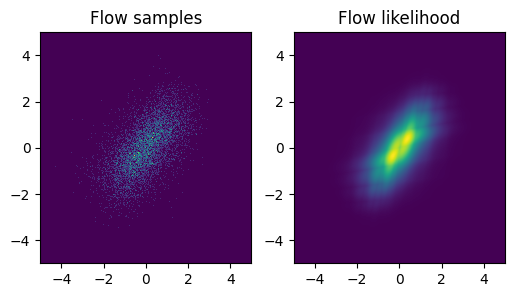

 50%|████▉     | 498/1000 [00:22<00:20, 24.43it/s]

Current training loss: 3.276


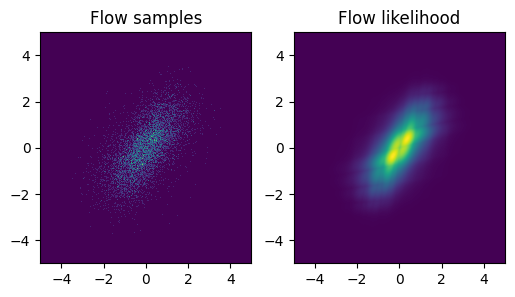

 60%|█████▉    | 598/1000 [00:26<00:15, 26.53it/s]

Current training loss: 3.546


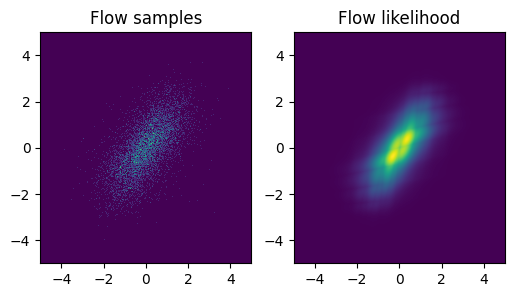

 70%|██████▉   | 698/1000 [00:30<00:12, 24.78it/s]

Current training loss: 3.473


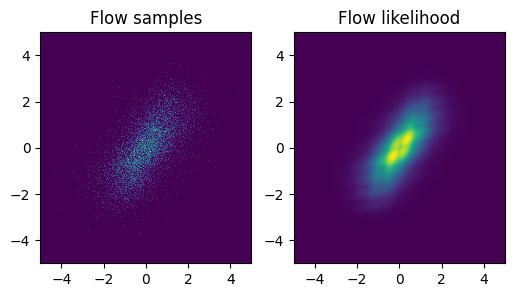

 80%|███████▉  | 797/1000 [00:35<00:08, 24.16it/s]

Current training loss: 4.890


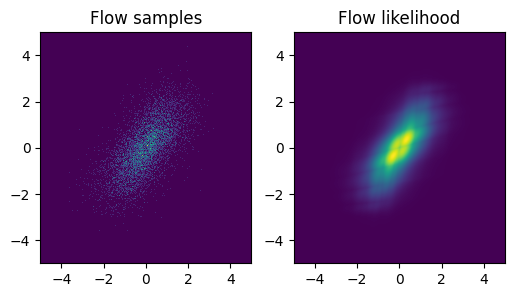

 90%|████████▉ | 898/1000 [00:39<00:04, 23.92it/s]

Current training loss: 4.557


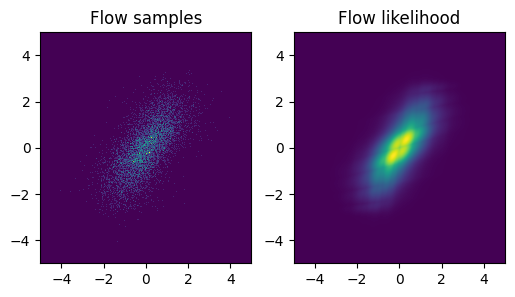

100%|█████████▉| 999/1000 [00:43<00:00, 32.04it/s]

Current training loss: 3.605


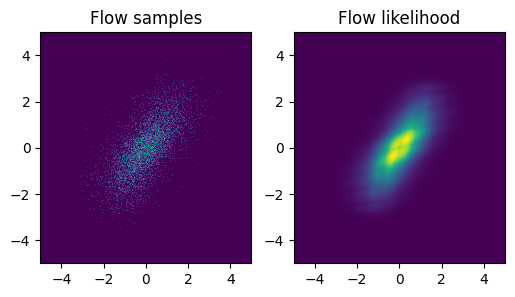

100%|██████████| 1000/1000 [00:43<00:00, 22.80it/s]


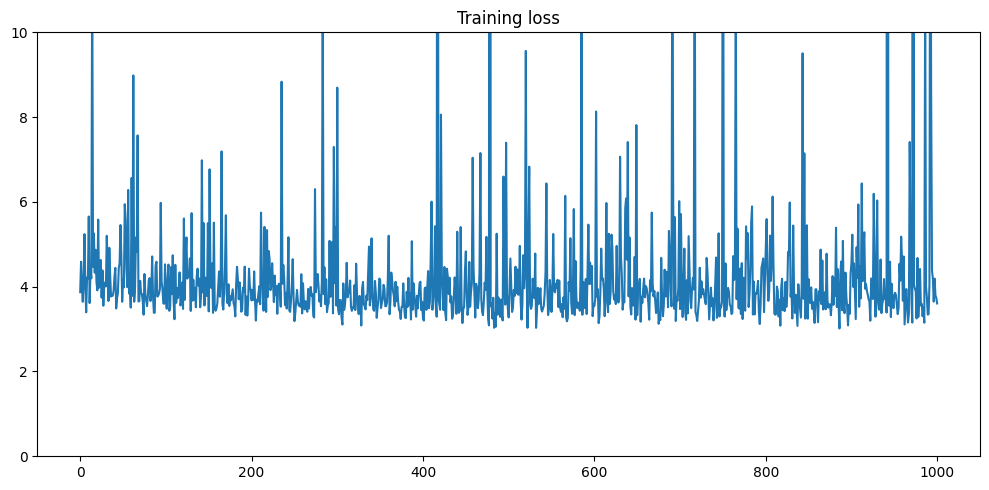

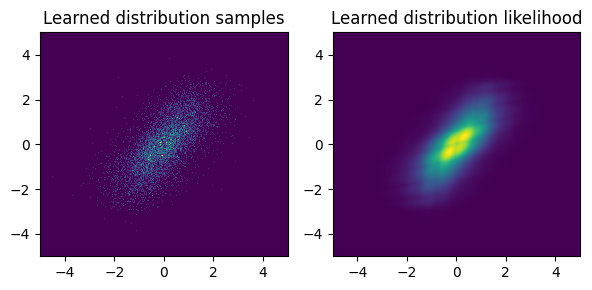

In [ ]:
# Construct flow model
nfm = nf.NormalizingFlow(q0=q0, flows=build_flows())
nfm = nfm.to(device)

# Train model
train(nfm)

In [ ]:
# Compute average NLL per sample and dim
nll_baseline = get_nll(nfm, torch.from_numpy(x_np).to(device))
print(f"Average NLL: {nll_baseline:.3f}")

# Count samples in bin around 0
num_true_samps_in_bin_dim0, num_flow_samps_in_bin_dim0 = bin_count(nfm, torch.from_numpy(x_np).to(device), 0)
print(f"Num true samps, num flow samps in bin (dim 0): {num_true_samps_in_bin_dim0}, {num_flow_samps_in_bin_dim0}")
num_true_samps_in_bin_dim1, num_flow_samps_in_bin_dim1 = bin_count(nfm, torch.from_numpy(x_np).to(device), 1)
print(f"Num true samps, num flow samps in bin (dim 1): {num_true_samps_in_bin_dim1}, {num_flow_samps_in_bin_dim1}")

Average NLL: 2.072
Num true samps, num flow samps in bin (dim 0): 1227, 1275
Num true samps, num flow samps in bin (dim 1): 1152, 1156


### TTF models

In [4]:
# True tailparams
pos_tail_init = torch.tensor([1.0, 1.0])
neg_tail_init = torch.tensor([1.0, 1.0])

# Shift and scale
shift_init = torch.tensor([1.0, -1.0])
scale_init = torch.tensor([2.0, 0.5])

Standard TTF: No breaking points needed, thus fixed.
Fixed breakpoint params.


 48%|████▊     | 97/200 [00:04<00:04, 23.42it/s]

Current training loss: 2.928


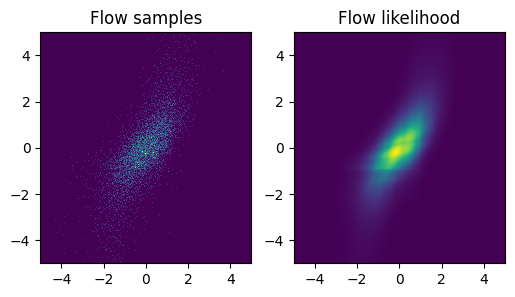

 52%|█████▏    | 103/200 [00:04<00:07, 12.79it/s]

pos_tail:  tensor([0.9366, 0.9368], device='cuda:3', grad_fn=<SoftplusBackward0>)
neg_tail:  tensor([0.9387, 0.9374], device='cuda:3', grad_fn=<SoftplusBackward0>)
shift:  Parameter containing:
tensor([ 0.9012, -0.9006], device='cuda:3', requires_grad=True)
scale:  tensor([1.9139, 0.5403], device='cuda:3', grad_fn=<AddBackward0>)


100%|█████████▉| 199/200 [00:09<00:00, 23.52it/s]

Current training loss: 2.844


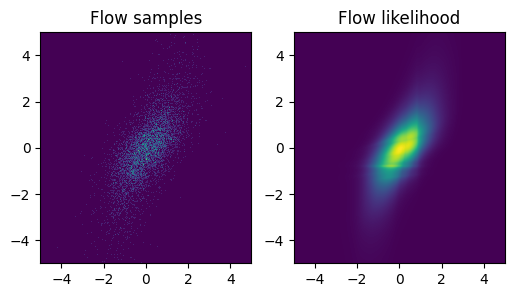

100%|██████████| 200/200 [00:09<00:00, 21.14it/s]

pos_tail:  tensor([0.8715, 0.8737], device='cuda:3', grad_fn=<SoftplusBackward0>)
neg_tail:  tensor([0.8812, 0.8754], device='cuda:3', grad_fn=<SoftplusBackward0>)
shift:  Parameter containing:
tensor([ 0.8041, -0.8054], device='cuda:3', requires_grad=True)
scale:  tensor([1.8261, 0.5784], device='cuda:3', grad_fn=<AddBackward0>)


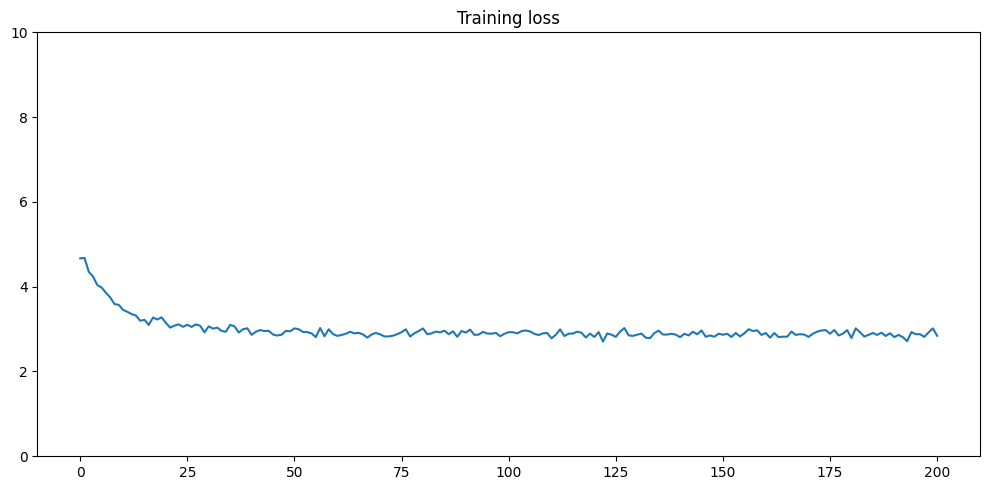

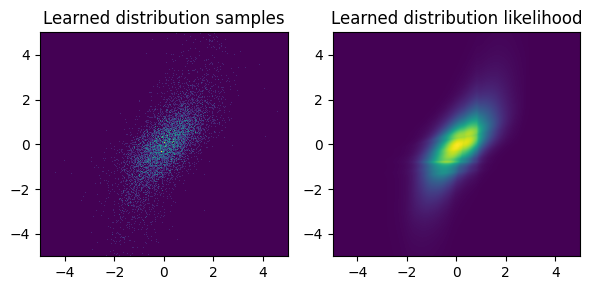

In [6]:
# Standard TTF
ttf_layer = ModifiedTailAffineMarginalTransform(
    features=2,
    pos_tail_init=pos_tail_init.detach().clone(),
    neg_tail_init=neg_tail_init.detach().clone(),
    shift_init=shift_init.detach().clone(),
    scale_init=scale_init.detach().clone(),
    hd_only=False,
    mod="std",
    fix_params=False,
)

# Construct flow model
nfm_ttf = nf.NormalizingFlow(q0=q0, flows=build_flows() + [ttf_layer])
nfm_ttf = nfm_ttf.to(device)

# Train
train(nfm_ttf, 200)

In [7]:
print("TTF parameters after training:")
print("pos_tail: ", ttf_layer.pos_tail)
print("neg_tail: ", ttf_layer.neg_tail)
print("shift: ", ttf_layer.shift)
print("scale: ", ttf_layer.scale)

TTF parameters after training:
pos_tail:  tensor([0.8715, 0.8737], device='cuda:3', grad_fn=<SoftplusBackward0>)
neg_tail:  tensor([0.8812, 0.8754], device='cuda:3', grad_fn=<SoftplusBackward0>)
shift:  Parameter containing:
tensor([ 0.8041, -0.8054], device='cuda:3', requires_grad=True)
scale:  tensor([1.8261, 0.5784], device='cuda:3', grad_fn=<AddBackward0>)


In [7]:
# Compute average NLL per sample and dim
nll_ttf = get_nll(nfm_ttf, torch.from_numpy(x_np).to(device))
print(f"Average NLL: {nll_ttf:.3f}")

# Count samples in bin around 0
num_true_samps_in_bin_dim0, num_flow_samps_in_bin_dim0 = bin_count(nfm_ttf, torch.from_numpy(x_np).to(device), 0)
print(f"Num true samps, num flow samps in bin (dim 0): {num_true_samps_in_bin_dim0}, {num_flow_samps_in_bin_dim0}")
num_true_samps_in_bin_dim1, num_flow_samps_in_bin_dim1 = bin_count(nfm_ttf, torch.from_numpy(x_np).to(device), 1)
print(f"Num true samps, num flow samps in bin (dim 1): {num_true_samps_in_bin_dim1}, {num_flow_samps_in_bin_dim1}")

Average NLL: 1.438
Num true samps, num flow samps in bin (dim 0): 1258, 1271
Num true samps, num flow samps in bin (dim 1): 1221, 1278


### Original TTF implementation

0 1


 50%|████▉     | 99/200 [00:04<00:04, 23.84it/s]

Current training loss: 2.922


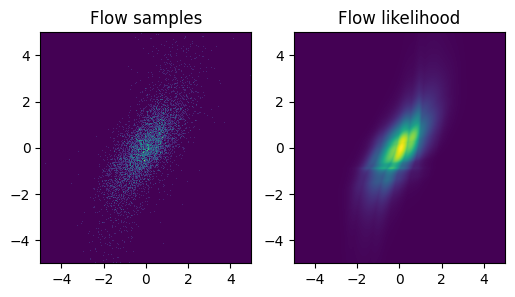

pos_tail:  tensor([0.9365, 0.9365], device='cuda:3', grad_fn=<SoftplusBackward0>)
neg_tail:  

 52%|█████▎    | 105/200 [00:04<00:06, 14.46it/s]

tensor([0.9386, 0.9378], device='cuda:3', grad_fn=<SoftplusBackward0>)
shift:  Parameter containing:
tensor([ 0.9010, -0.9006], device='cuda:3', requires_grad=True)
scale:  tensor([1.9140, 0.5403], device='cuda:3', grad_fn=<AddBackward0>)


 99%|█████████▉| 198/200 [00:08<00:00, 23.83it/s]

Current training loss: 2.963


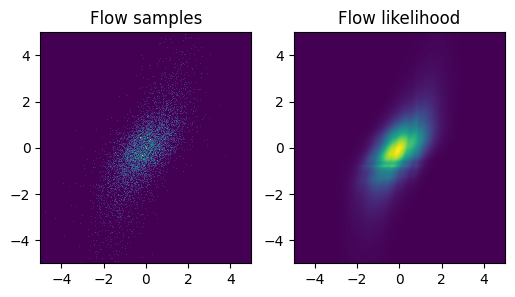

100%|██████████| 200/200 [00:09<00:00, 21.77it/s]

pos_tail:  tensor([0.8709, 0.8738], device='cuda:3', grad_fn=<SoftplusBackward0>)
neg_tail:  tensor([0.8813, 0.8756], device='cuda:3', grad_fn=<SoftplusBackward0>)
shift:  Parameter containing:
tensor([ 0.8047, -0.8057], device='cuda:3', requires_grad=True)
scale:  tensor([1.8261, 0.5786], device='cuda:3', grad_fn=<AddBackward0>)


3 205


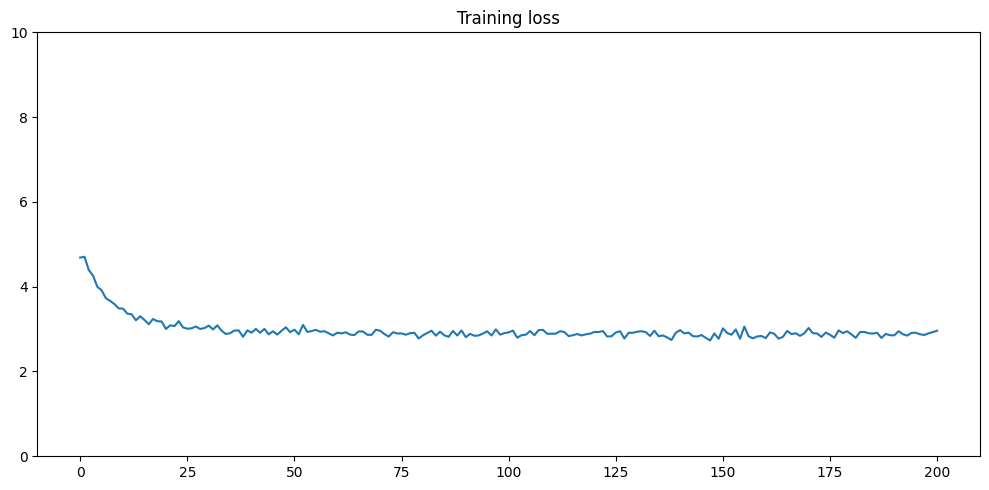

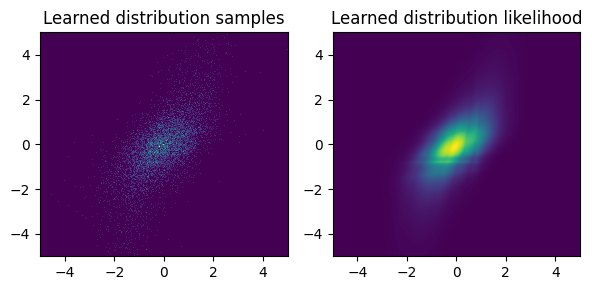

In [8]:
# Standard TTF
ttf_orig_layer = TailAffineMarginalTransform(
    features=2,
    pos_tail_init=pos_tail_init.detach().clone(),
    neg_tail_init=neg_tail_init.detach().clone(),
    shift_init=shift_init.detach().clone(),
    scale_init=scale_init.detach().clone(),
)
# ttf_layer.fix_tails()

# Construct flow model
nfm_ttf_orig = nf.NormalizingFlow(q0=q0, flows=build_flows() + [ttf_orig_layer])
nfm_ttf_orig = nfm_ttf_orig.to(device)

loss = nfm_ttf_orig.forward_kld(torch.from_numpy(x_np).to(dtype=DEFAULT_DTYPE, device=device))
print(ttf_orig_layer.forward_calls, ttf_orig_layer.inverse_calls)

# Train
train(nfm_ttf_orig, 200)

print(ttf_orig_layer.forward_calls, ttf_orig_layer.inverse_calls)

In [9]:
print("TTF parameters after training:")
print("pos_tail: ", ttf_orig_layer.pos_tail)
print("neg_tail: ", ttf_orig_layer.neg_tail)
print("shift: ", ttf_orig_layer.shift)
print("scale: ", ttf_orig_layer.scale)

TTF parameters after training:
pos_tail:  tensor([0.8709, 0.8738], device='cuda:3', grad_fn=<SoftplusBackward0>)
neg_tail:  tensor([0.8813, 0.8756], device='cuda:3', grad_fn=<SoftplusBackward0>)
shift:  Parameter containing:
tensor([ 0.8047, -0.8057], device='cuda:3', requires_grad=True)
scale:  tensor([1.8261, 0.5786], device='cuda:3', grad_fn=<AddBackward0>)


In [ ]:
# Compute average NLL per sample and dim
nll_ttf_orig = get_nll(nfm_ttf_orig, torch.from_numpy(x_np).to(device))
print(f"Average NLL: {nll_ttf_orig:.3f}")

# Count samples in bin around 0
num_true_samps_in_bin_dim0, num_flow_samps_in_bin_dim0 = bin_count(nfm_ttf_orig, torch.from_numpy(x_np).to(device), 0)
print(f"Num true samps, num flow samps in bin (dim 0): {num_true_samps_in_bin_dim0}, {num_flow_samps_in_bin_dim0}")
num_true_samps_in_bin_dim1, num_flow_samps_in_bin_dim1 = bin_count(nfm_ttf_orig, torch.from_numpy(x_np).to(device), 1)
print(f"Num true samps, num flow samps in bin (dim 1): {num_true_samps_in_bin_dim1}, {num_flow_samps_in_bin_dim1}")

Average NLL: 1.434
Num true samps, num flow samps in bin (dim 0): 1262, 1192
Num true samps, num flow samps in bin (dim 1): 1110, 1104


### Debugging

In [ ]:
import copy

torch.manual_seed(123)
flows_base = build_flows()

flows_orig = copy.deepcopy(flows_base)
flows_mod = copy.deepcopy(flows_base)

# True tailparams
pos_tail_init = torch.tensor([1.0, 1.0])
neg_tail_init = torch.tensor([1.0, 1.0])

# Shift and scale
shift_init = torch.tensor([1.0, -1.0])
scale_init = torch.tensor([2.0, 0.5])

ttf_orig_layer = TailAffineMarginalTransform(
    features=2,
    pos_tail_init=pos_tail_init.detach().clone(),
    neg_tail_init=neg_tail_init.detach().clone(),
    shift_init=shift_init.detach().clone(),
    scale_init=scale_init.detach().clone(),
)
ttf_mod_layer = ModifiedTailAffineMarginalTransform(
    features=2,
    pos_tail_init=pos_tail_init.detach().clone(),
    neg_tail_init=neg_tail_init.detach().clone(),
    shift_init=shift_init.detach().clone(),
    scale_init=scale_init.detach().clone(),
)

model_orig = nf.NormalizingFlow(q0=copy.deepcopy(q0), flows=flows_orig + [ttf_orig_layer]).to(device)
model_mod = nf.NormalizingFlow(q0=copy.deepcopy(q0), flows=flows_orig + [ttf_mod_layer]).to(device)

Standard TTF: No breaking points needed, thus fixed.
Fixed breakpoint params.


In [20]:
x = target.sample(32000).float().to(device)

with torch.no_grad():
    lp_orig = model_orig.log_prob(x)
    lp_mod = model_mod.log_prob(x)

print("log_prob max diff:", (lp_orig - lp_mod).abs().max())
print("log_prob mean diff:", (lp_orig - lp_mod).abs().mean())

log_prob max diff: tensor(1.9073e-06, device='cuda:3')
log_prob mean diff: tensor(1.6721e-07, device='cuda:3')


In [ ]:
from tailnflows.models.extreme_transformations import _extreme_transform_and_lad, _ttf_sym_value_and_logprime

z = torch.linspace(0.0, 6.0, 20).unsqueeze(dim=-1)
# print("z: ", z)

x1, lad1 = _ttf_sym_value_and_logprime(z, torch.tensor([1.0]))
x2, lad2 = _extreme_transform_and_lad(z, torch.tensor([1.0]))

print("x2-x1: ", x2-x1)

print("max |x1-x2|:", (x1 - x2).abs().max())
print("max |lad1-lad2|:", (lad1 - lad2).abs().max())

x = torch.linspace(0.0, 6.0, 1000).unsqueeze(dim=-1)
# print("z: ", z)

z1, lad1 = _ttf_sym_value_and_logprime(x, torch.tensor([1.0]))
z2, lad2 = _extreme_transform_and_lad(x, torch.tensor([1.0]))

print("max |z1-z2|:", (z1 - z2).abs().max())
print("max |lad1-lad2|:", (lad1 - lad2).abs().max())

x2-x1:  tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]])
max |x1-x2|: tensor(0.)
max |lad1-lad2|: tensor(2.3842e-07)
max |z1-z2|: tensor(0.)
max |lad1-lad2|: tensor(2.3842e-07)


In [5]:
import copy

# True tailparams
pos_tail_init = torch.tensor([1.0, 1.0])
neg_tail_init = torch.tensor([1.0, 1.0])

# Shift and scale
shift_init = torch.tensor([1.0, -1.0])
scale_init = torch.tensor([2.0, 0.5])

torch.manual_seed(123)
torch.cuda.manual_seed_all(123)

base_flows = build_flows()
flows_a = copy.deepcopy(base_flows)
flows_b = copy.deepcopy(base_flows)

layer_a = TailAffineMarginalTransform(
    2,
    pos_tail_init=pos_tail_init.clone(),
    neg_tail_init=neg_tail_init.clone(),
    shift_init=shift_init.clone(),
    scale_init=scale_init.clone(),
)

layer_b = ModifiedTailAffineMarginalTransform(
    2,
    pos_tail_init=pos_tail_init.clone(),
    neg_tail_init=neg_tail_init.clone(),
    shift_init=shift_init.clone(),
    scale_init=scale_init.clone(),
    hd_only=False,
    mod="std",
    fix_params=False,
)

model_a = nf.NormalizingFlow(q0=copy.deepcopy(q0), flows=flows_a + [layer_a]).to(device)
model_b = nf.NormalizingFlow(q0=copy.deepcopy(q0), flows=flows_b + [layer_b]).to(device)

In [6]:
x = target.sample(128000).float().to(device)

with torch.no_grad():
    print((model_a.log_prob(x) - model_b.log_prob(x)).abs().max())

tensor(1.9073e-06, device='cuda:3')


In [16]:
debug_first_steps(model_a, model_b, layer_a, layer_b)


STEP 0
loss_a 4.657377243041992 loss_b 4.657377243041992 diff 0.0
BEFORE STEP
_unc_pos_tail param diff 0.0 grad diff 1.4901161193847656e-08 grad a [0.01587194 0.04993522] grad b [0.01587194 0.04993524]
_unc_neg_tail param diff 0.0 grad diff 1.862645149230957e-09 grad a [0.13201824 0.014118  ] grad b [0.13201824 0.01411801]
shift param diff 0.0 grad diff 0.0 grad a [ 0.40360707 -0.73240376] grad b [ 0.40360707 -0.73240376]
_unc_scale param diff 0.0 grad diff 8.940696716308594e-08 grad a [ 0.14224549 -0.23464067] grad b [ 0.14224552 -0.23464058]
AFTER STEP / UPDATE DIFF
_unc_pos_tail update a [-0.00099999 -0.00099999] update b [-0.00099999 -0.00099999] update diff 0.0 new param diff 0.0
_unc_neg_tail update a [-0.00099999 -0.00099999] update b [-0.00099999 -0.00099999] update diff 0.0 new param diff 0.0
shift update a [-0.00099999  0.00099999] update b [-0.00099999  0.00099999] update diff 0.0 new param diff 0.0
_unc_scale update a [-0.00100005  0.00099999] update b [-0.00100005  0.0009

### Modified TTF layers

Fixed tailparams.
Fixed location params.
Fixed scale params.
Fixed breakpoint params.


 10%|▉         | 99/1000 [00:09<01:29, 10.07it/s]

Current training loss: 3.229


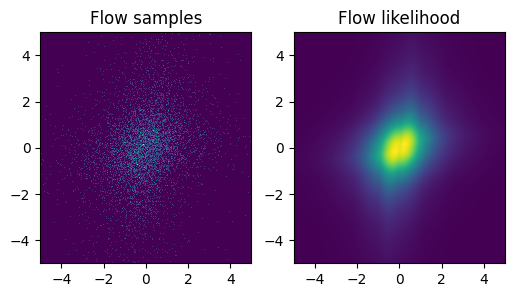

 20%|█▉        | 198/1000 [00:19<01:16, 10.49it/s]

Current training loss: 3.049


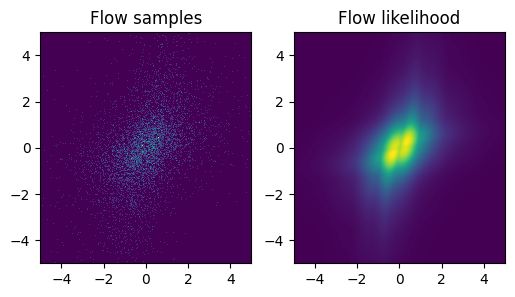

 30%|██▉       | 298/1000 [00:30<01:07, 10.45it/s]

Current training loss: 3.071


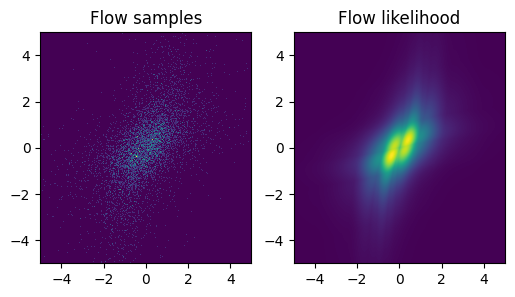

 40%|███▉      | 399/1000 [00:40<00:58, 10.26it/s]

Current training loss: 3.039


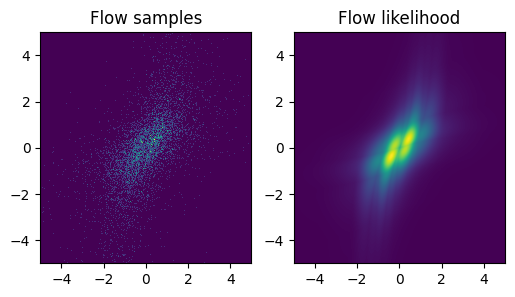

 50%|████▉     | 498/1000 [00:50<00:48, 10.27it/s]

Current training loss: 2.896


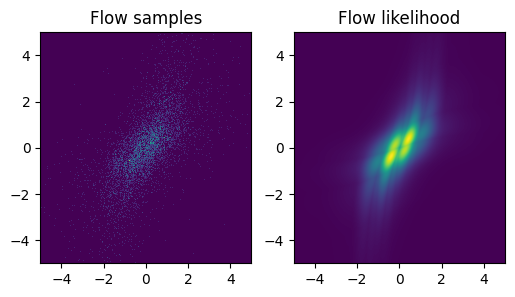

 60%|█████▉    | 598/1000 [01:00<00:35, 11.36it/s]

Current training loss: 2.969


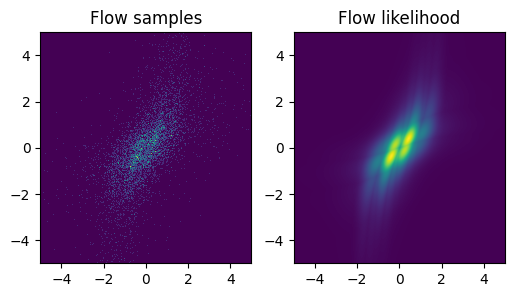

 70%|██████▉   | 698/1000 [01:10<00:29, 10.28it/s]

Current training loss: 2.936


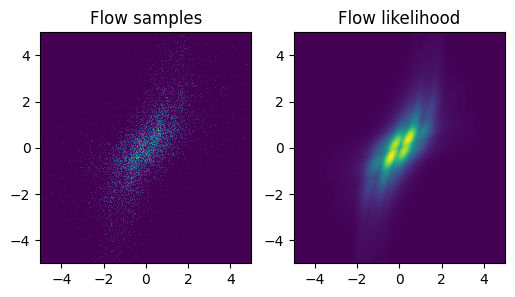

 80%|███████▉  | 798/1000 [01:20<00:19, 10.11it/s]

Current training loss: 2.940


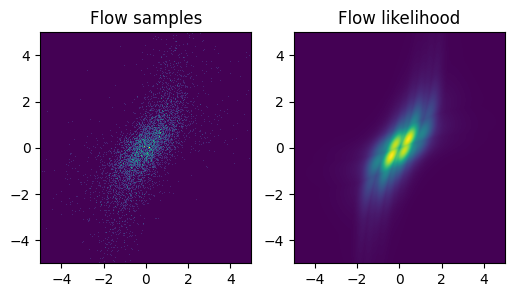

 90%|████████▉ | 898/1000 [01:31<00:10, 10.07it/s]

Current training loss: 2.863


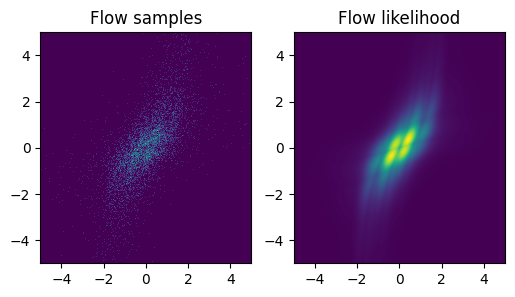

100%|█████████▉| 999/1000 [01:41<00:00, 10.02it/s]

Current training loss: 2.845


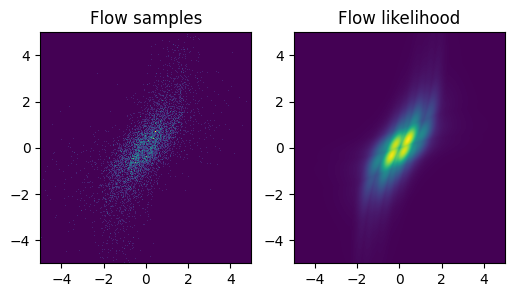

100%|██████████| 1000/1000 [01:42<00:00,  9.77it/s]


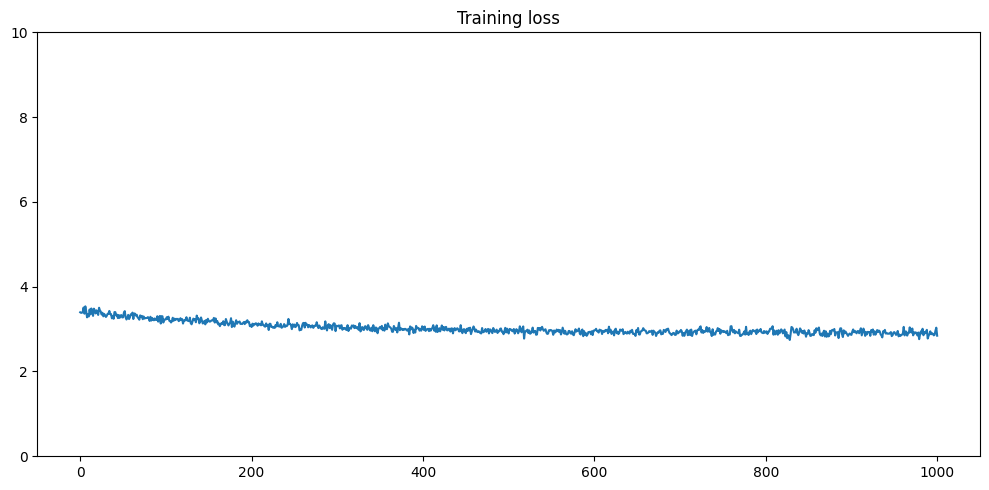

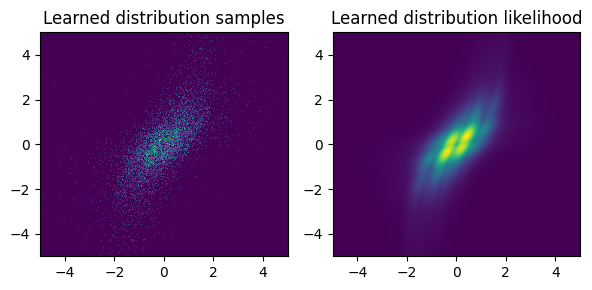

In [ ]:
# erfi-based TTF on heavy-directions only with fixed parameters
ttf_erfi_layer = ModifiedTailAffineMarginalTransform(
    features=2,
    pos_tail_init=pos_tail_init,
    neg_tail_init=neg_tail_init,
    hd_only=False,
    mod="erfi",
    fix_params=True,
)

# Construct flow model
nfm_ttf_erfi = nf.NormalizingFlow(q0=q0, flows=build_flows() + [ttf_erfi_layer])
nfm_ttf_erfi = nfm_ttf_erfi.to(device)

# Train
train(nfm_ttf_erfi)

In [ ]:
# Compute average NLL per sample and dim
nll_ttf_erfi = get_nll(nfm_ttf_erfi, torch.from_numpy(x_np).to(device))
print(f"Average NLL: {nll_ttf_erfi:.3f}")

# Count samples in bin around 0
num_true_samps_in_bin_dim0, num_flow_samps_in_bin_dim0 = bin_count(nfm_ttf_erfi, torch.from_numpy(x_np).to(device), 0)
print(f"Num true samps, num flow samps in bin (dim 0): {num_true_samps_in_bin_dim0}, {num_flow_samps_in_bin_dim0}")
num_true_samps_in_bin_dim1, num_flow_samps_in_bin_dim1 = bin_count(nfm_ttf_erfi, torch.from_numpy(x_np).to(device), 1)
print(f"Num true samps, num flow samps in bin (dim 1): {num_true_samps_in_bin_dim1}, {num_flow_samps_in_bin_dim1}")

Average NLL: 1.458
Num true samps, num flow samps in bin (dim 0): 1313, 1203
Num true samps, num flow samps in bin (dim 1): 1140, 1109


In [20]:
torch.cuda.empty_cache()